In [155]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper


In [156]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2,
                                    doc_content_chars_max=500)

arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv,
                      description="Query Arxiv Papers")

print(arxiv.name)

arxiv


In [157]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [158]:
api_wrapper_wikipedia = WikipediaAPIWrapper(
    top_k_results=1,
    doc_content_chars_max=500
)

wikipedia = WikipediaQueryRun(
    api_wrapper=api_wrapper_wikipedia,
    description="Query Wikipedia"
)

print(wikipedia.name)

wikipedia


In [159]:
from langchain_community.tools import TavilySearchResults
tavily = TavilySearchResults()

In [160]:
tavily.invoke("Provide me the Recent AI News")

[{'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
  'url': 'https://www.artificialintelligence-news.com',
  'content': "Finance AI\n\nAugust 26, 2025\n\n### Google’s Veo 3 AI video creation tools are now widely available\n\nAI in Action\n\nJuly 29, 2025\n\n#### Computer Vision\n\n### Microsoft’s Majorana 2 quantum chip is also a case study for agentic AI in R&D\n\nInside AI\n\nJune 3, 2026\n\n### US and Japan announce sweeping AI and tech collaboration\n\nArtificial Intelligence\n\nApril 11, 2024\n\n### UK and Canada sign AI compute agreement\n\nArtificial Intelligence\n\nJanuary 31, 2024\n\n#### Machine Learning\n\n### Aviva deploys AI to stop £230M in sophisticated insurance fraud\n\nAI in Action\n\nJune 8, 2026\n\n### Google folds Display Ads into AI-first Demand Gen platform\n\nMarketing AI\n\nMay 27, 2026\n\n### IDC: How EMEA CIOs can jumpstart AI rollouts\n\nGovernance, Regulation & Policy\n\nApril 29, 2026\n\n#### Enterprise [...] April 29, 2026\n

In [161]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

#### Combine All The Tools

### Tavily, Arxiv, Wikipedia

### Initilize The LLM Model

In [162]:
tools = [arxiv, wikipedia, tavily]

In [163]:


from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
llm = ChatGroq(
    model="llama-3.3-70b-versatile"
)

SYSTEM = SystemMessage(content=(
    "You are a helpful assistant. "
    "Only use tools when the question genuinely requires current information "
    "or academic papers. For general knowledge questions, answer directly."
))

In [164]:
llm.invoke("What is AI")

AIMessage(content="**Artificial Intelligence (AI)** refers to the development of computer systems that can perform tasks that typically require human intelligence, such as:\n\n* Learning\n* Problem-solving\n* Reasoning\n* Perception\n* Understanding language\n\nAI involves the use of algorithms, statistical models, and computer programming to enable machines to make decisions and take actions without being explicitly programmed for every possible scenario.\n\n**Key Characteristics of AI:**\n\n1. **Machine Learning**: AI systems can learn from data and improve their performance over time.\n2. **Autonomy**: AI systems can operate independently, making decisions and taking actions without human intervention.\n3. **Reasoning and Problem-Solving**: AI systems can analyze data, identify patterns, and make decisions based on that analysis.\n4. **Natural Language Processing**: AI systems can understand and generate human-like language.\n\n**Types of AI:**\n\n1. **Narrow or Weak AI**: Designed 

In [165]:
llm_with_tools = llm.bind_tools(tools = tools)

In [166]:
llm_with_tools.invoke("What is The Recent News of AI")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'vxydnjwvv', 'function': {'arguments': '{"query":"Recent News of AI"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 392, 'total_tokens': 413, 'completion_time': 0.062817913, 'completion_tokens_details': None, 'prompt_time': 0.019882783, 'prompt_tokens_details': None, 'queue_time': 0.161751605, 'total_time': 0.082700696}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb065-560c-76e0-b38c-a03e53358798-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Recent News of AI'}, 'id': 'vxydnjwvv', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 392, 'output_tokens': 21, 'total_tokens': 413})

In [167]:
llm_with_tools.invoke("What is The Latest Reserach on Quantum Computing")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '118a7j2g0', 'function': {'arguments': '{"query":"quantum computing"}', 'name': 'arxiv'}, 'type': 'function'}, {'id': '8gttspfw7', 'function': {'arguments': '{"query":"latest research on quantum computing"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 395, 'total_tokens': 433, 'completion_time': 0.116166448, 'completion_tokens_details': None, 'prompt_time': 0.038548792, 'prompt_tokens_details': None, 'queue_time': 0.161411156, 'total_time': 0.15471524}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb065-5761-7f60-8573-c95903c4784c-0', tool_calls=[{'name': 'arxiv', 'args': {'query': 'quantum computing'}, 'id': '118a7j2g0', 'type': 'tool_call'}, {'name': 'tavily_search_results_js

In [168]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
from typing import List

In [169]:



from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage

class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    

In [170]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [171]:
llm_with_tools = llm.bind_tools(tools=tools, tool_choice="auto")

def ToolCalling(state: State):
    msgs = [SYSTEM] + state["messages"]
    try:
        response = llm_with_tools.invoke(msgs)
    except Exception as e:
        if "tool_use_failed" in str(e) or "400" in str(e):
            # Groq mangled the tool call — retry without tools
            response = llm.invoke(msgs)
        else:
            raise
    return {"messages": [response]}

In [172]:
builder = StateGraph(State)
builder.add_node("ToolCalling", ToolCalling)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "ToolCalling")
builder.add_conditional_edges("ToolCalling", tools_condition)
builder.add_edge("tools", "ToolCalling")   # loop back after tool runs

graph = builder.compile()

In [173]:


from langchain_core.messages import HumanMessage

messages = graph.invoke({
    "messages": "1706.03762"})

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (pv26fdwn7)
 Call ID: pv26fdwn7
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base
================================== Ai Message ==================================

The provided code, 1706.03762, is a reference to an Arxiv paper tit

In [174]:
print("=" * 60)
print("TEST 1: General knowledge (no tool needed)")
print("=" * 60)
response = graph.invoke({
    "messages": [HumanMessage(content="What is Machine Learning?")]
})
for msg in response["messages"]:
    msg.pretty_print()

print("\n" + "=" * 60)
print("TEST 2: Needs tool (arxiv paper)")
print("=" * 60)
response = graph.invoke({
    "messages": [HumanMessage(content="Search arxiv for: 1706.03762")]
})
for msg in response["messages"]:
    msg.pretty_print()

TEST 1: General knowledge (no tool needed)
================================ Human Message =================================

What is Machine Learning?
================================== Ai Message ==================================

Machine learning is a subset of artificial intelligence that involves the use of algorithms and statistical models to enable machines to perform a specific task without using explicit instructions. Instead, the machine learns from data, making predictions or decisions based on that data. It's a field of study that focuses on the development of algorithms and statistical models that allow machines to learn from data, making it possible for them to improve their performance on a task over time.

TEST 2: Needs tool (arxiv paper)
================================ Human Message =================================

Search arxiv for: 1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (tr9wv9fax)
 Call ID: t

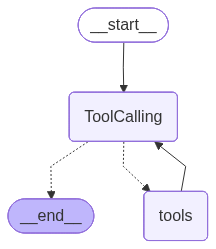

In [175]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [176]:
print("=" * 60)
print("TEST 1: General knowledge (no tool needed)")
print("=" * 60)
response = graph.invoke({
    "messages": [HumanMessage(content="My Name is Monirul Now Please Tell Me Recent Research Papper Baseed on Quantum Computing")]
})
for msg in response["messages"]:
    msg.pretty_print()

TEST 1: General knowledge (no tool needed)
================================ Human Message =================================

My Name is Monirul Now Please Tell Me Recent Research Papper Baseed on Quantum Computing
================================== Ai Message ==================================
Tool Calls:
  arxiv (dy8c2gj61)
 Call ID: dy8c2gj61
  Args:
    query: Quantum Computing recent papers
================================= Tool Message =================================
Name: arxiv

Published: 2025-04-07
Title: Quantum Computing: Vision and Challenges
Authors: Sukhpal Singh Gill, Oktay Cetinkaya, Stefano Marrone, Daniel Claudino, David Haunschild, Leon Schlote, Huaming Wu, Carlo Ottaviani, Xiaoyuan Liu, Sree Pragna Machupalli, Kamalpreet Kaur, Priyansh Arora, Ji Liu, Ahmed Farouk, Houbing Herbert Song, Steve Uhlig, Kotagiri Ramamohanarao
Summary: The recent development of quantum computing, which uses entanglement, superposition, and other quantum fundamental concepts, can 
=======

In [177]:
print("=" * 60)
print("TEST 1: General knowledge (no tool needed)")
print("=" * 60)
response = graph.invoke({
    "messages": [HumanMessage(content="What is Machine Learning? and Please Tell Me Recent Research Papper Baseed on Quantum Computing")]
})
for msg in response["messages"]:
    msg.pretty_print()

TEST 1: General knowledge (no tool needed)
================================ Human Message =================================

What is Machine Learning? and Please Tell Me Recent Research Papper Baseed on Quantum Computing
================================== Ai Message ==================================

**What is Machine Learning?**

Machine Learning (ML) is a subset of artificial intelligence (AI) that involves training algorithms to learn from data and make predictions or decisions without being explicitly programmed. It's a type of AI that enables systems to improve their performance on a task over time, based on experience and data.

The process of machine learning typically involves:

1. Data collection: Gathering data relevant to the problem you want to solve.
2. Data preprocessing: Cleaning, transforming, and preparing the data for training.
3. Model selection: Choosing a suitable machine learning algorithm and configuring it.
4. Training: Feeding the data to the algorithm to lear